# Proyecciones climáticas con datos grillados: climatología, anomalías y tendencia

**Geocomputación (1GEO20)** — PUCP, 2026-II — Semana 6


En este notebook procesamos datos grillados de proyecciones climáticas: cálculo de climatología, anomalías, promedio espacial y tendencia, para una región de estudio.

**Datos:** [NASA NEX-GDDP-CMIP6](https://developers.google.com/earth-engine/datasets/catalog/NASA_GDDP-CMIP6), variable `tasmax`, recortados a la región Lon(-85, -65) / Lat(-20, 5). 2 modelos (ACCESS-CM2, CMCC-ESM2), histórico (1950-2014) y 2 escenarios (SSP2-4.5, SSP5-8.5) hasta 2099, resolución mensual.

## 0. Descargar los datos 


In [ ]:
# Alternativa para descargar la carpeta compartida de Google Drive
# Descomenta y reemplaza el ID por el de la carpeta compartida

#!pip install gdown -q

In [1]:
import gdown
gdown.download_folder(id="1ZP-yqBKVZ8bYkbnxJL_hQpxl0qz9MP-6", output="datos_proyecciones", quiet=False)

# # o en Collab
# Descomenta y reemplaza el ID por el de la carpeta compartida
# !gdown --folder "ID_DE_LA_CARPETA_COMPARTIDA" -O datos_proyecciones

Retrieving folder contents


Retrieving folder 1QwR9SnzDrOtFPhrbjmixte73DtF2onh0 pr
Retrieving folder 1udLNYN2s1MBF9essbIf4b6mBO25nyc02 ACCESS-CM2
Processing file 1eX5jBhba3YqY-_PplFC7JKAgdd31RcSa pr_ACCESS-CM2_1950-2014_historical.nc
Processing file 1O_LWVS34T2RY3f3Lj37on0bPXnMrwfOn pr_ACCESS-CM2_2015-2049_ssp245.nc
Processing file 1Iu6XcPRBvvR1P8DT_t11ru8PmrYZyBnS pr_ACCESS-CM2_2015-2049_ssp585.nc
Processing file 1EYoHZwjKP2DGcSlcWxX1gWDbCiJSCQM3 pr_ACCESS-CM2_2050-2099_ssp245.nc
Processing file 1mzvZ5zcyVubraTLiQBMoCcBWmAMaIgrn pr_ACCESS-CM2_2050-2099_ssp585.nc
Retrieving folder 1gULI7KQN6xuK3L7L4uQk0HXZft-W8_9F CMCC-ESM2
Processing file 1JMacFqdpw4wAwcklf4dgkfOFy9gZDqoP pr_CMCC-ESM2_1950-2014_historical.nc
Processing file 12tpPIpevwxFnbU70k_XHg8NLNPxNf__U pr_CMCC-ESM2_2015-2049_ssp245.nc
Processing file 1IcowaX2lxWnuP-uVC7PVqye2vOeLq2jC pr_CMCC-ESM2_2015-2049_ssp585.nc
Processing file 1HOlAHVZy6TTFDQLsUAwj_F3HhE3ccg1X pr_CMCC-ESM2_2050-2099_ssp245.nc
Processing file 12G1IQX4k6ASVGrbGCDxOEG6kM4Cet3px pr_CMCC-ES

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1eX5jBhba3YqY-_PplFC7JKAgdd31RcSa
To: c:\Users\sebas\OneDrive\Documentos\GitHub\geocomputacion\geocomputacion_-1GEO20-\ejercicios\ejercicios_aplicados\datos_proyecciones\pr\ACCESS-CM2\pr_ACCESS-CM2_1950-2014_historical.nc
100%|██████████| 25.0M/25.0M [00:01<00:00, 23.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1O_LWVS34T2RY3f3Lj37on0bPXnMrwfOn
To: c:\Users\sebas\OneDrive\Documentos\GitHub\geocomputacion\geocomputacion_-1GEO20-\ejercicios\ejercicios_aplicados\datos_proyecciones\pr\ACCESS-CM2\pr_ACCESS-CM2_2015-2049_ssp245.nc
100%|██████████| 13.5M/13.5M [00:00<00:00, 18.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Iu6XcPRBvvR1P8DT_t11ru8PmrYZyBnS
To: c:\Users\sebas\OneDrive\Documentos\GitHub\geocomputacion\geocomputacion_-1GEO20-\ejercicios\ejercicios_aplicados\datos_proyecciones\pr\ACCESS-CM2\pr_ACCESS

ConnectionError: ('Connection aborted.', ConnectionResetError(10054, 'Se ha forzado la interrupción de una conexión existente por el host remoto', None, 10054, None))

## 1. Setup y práctica con Xarray

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.stats import kendalltau, theilslopes

In [3]:
# Ejemplo con un solo modelo y un solo escenario

# Define direcciones como variables
carpeta_datos = "datos_proyecciones/"
modelo = "ACCESS-CM2"
escenario = "ssp585"

# 1. Cargar el histórico
ruta_historico = carpeta_datos + modelo + "/" + f"tasmax_{modelo}_1950-2014_historical.nc"
historico = xr.open_dataset(ruta_historico)

# 2. Cargar los dos tramos del escenario
carpeta_modelo = carpeta_datos + modelo + "/"
tramo1 = xr.open_dataset(carpeta_modelo + f"tasmax_{modelo}_2015-2049_{escenario}.nc")#["tasmax"]
tramo2 = xr.open_dataset(carpeta_modelo + f"tasmax_{modelo}_2050-2099_{escenario}.nc")#["tasmax"]

In [8]:
# 3. Concatenar todo en una sola variable continua 1950-2099. 'dim="x"' define la variable referencia para
# la concatenación; esta variable se mantiene incambiable
completo_ejemplo = xr.concat([historico, tramo1, tramo2], dim="time")
print(completo_ejemplo.sizes, completo_ejemplo.time.min().values, "a", completo_ejemplo.time.max().values)

Frozen({'time': 1800, 'y': 100, 'x': 80}) 1950-01-01T00:00:00.000000000 a 2099-12-01T00:00:00.000000000


In [9]:
# 4. Climatología: agrupa los pasos de tiempo por mes del calendario
# (todos los eneros juntos, todos los febreros juntos, ...) y promedia cada grupo
# Como la columna "time" está en formato "datetime", se puede llamar al mes como "time.month"
climatologia_ejemplo = completo_ejemplo.groupby("time.month").mean("time")
print(climatologia_ejemplo.sizes)  # queda (month: 12, lat, lon): un campo promedio por cada mes del año

Frozen({'month': 12, 'y': 100, 'x': 80})


In [10]:
climatologia_ejemplo

<xarray.Dataset> Size: 386kB
Dimensions:  (month: 12, y: 100, x: 80)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * y        (y) float64 800B 4.875 4.625 4.375 4.125 ... -19.38 -19.62 -19.88
  * x        (x) float64 640B -84.88 -84.62 -84.38 ... -65.62 -65.38 -65.12
Data variables:
    tasmax   (month, y, x) float32 384kB nan nan nan nan ... 296.8 298.3 297.7

## 2. Cargar todos los datos y armar series continuas

Cada modelo tiene su propia subcarpeta, con el histórico y dos tramos por escenario:

```
datos_proyecciones/
├── ACCESS-CM2/
│   ├── tasmax_ACCESS-CM2_1950-2014_historical.nc
│   ├── tasmax_ACCESS-CM2_2015-2049_ssp245.nc
│   ├── tasmax_ACCESS-CM2_2050-2099_ssp245.nc
│   ├── tasmax_ACCESS-CM2_2015-2049_ssp585.nc
│   └── tasmax_ACCESS-CM2_2050-2099_ssp585.nc
└── CMCC-ESM2/
    └── ... (misma estructura)
```

El histórico es el mismo para ambos escenarios de un modelo, así que lo cargamos **una sola vez por modelo** y lo combinamos con cada escenario.

In [11]:
carpeta_datos = "datos_proyecciones/"

modelos = ["ACCESS-CM2", "CMCC-ESM2"]
escenarios = ["ssp245", "ssp585"]  # tal cual aparecen en los nombres de archivo

In [12]:
# Para ambos arrays, solo se está agarrando la data de la variable "tasmax"
def cargar_historico(modelo, carpeta):
    ruta = carpeta + modelo + f"/tasmax_{modelo}_1950-2014_historical.nc"
    return xr.open_dataset(ruta)["tasmax"] # Devuelve un dataArray

def cargar_escenario(modelo, escenario, carpeta):
    carpeta_modelo = carpeta + modelo + "/"
    tramo1 = xr.open_dataset(carpeta_modelo + f"tasmax_{modelo}_2015-2049_{escenario}.nc")["tasmax"]
    tramo2 = xr.open_dataset(carpeta_modelo + f"tasmax_{modelo}_2050-2099_{escenario}.nc")["tasmax"]
    return xr.concat([tramo1, tramo2], dim="time")

In [ ]:
# Se define una lista inicial
da_por_modelo = []
for modelo in modelos:
    # Se asignan los datos históricos a una variable
    historico = cargar_historico(modelo, carpeta_datos)
    # Se define una variable que se reinicia tras cada iteración
    da_por_escenario = []
    # Como cada modelo tiene dos escenarios, se llama otra iteración para cada escenario del modelo
    for escenario in escenarios:
        # Se asignan los datos de las proyecciones correspondientes al modelo y escenario de la iteración
        futuro = cargar_escenario(modelo, escenario, carpeta_datos)
        # Se asigna a la lista la concatenación de la data histórica con la del escenario
        da_por_escenario.append(xr.concat([historico, futuro], dim="time")) #.append devuelve una lista
    # Con la data de ambos escenarios para un modelo, se concatenan los datos con referencia a la 
    # dimensión "escenario". Si la dimensión no existe, el comando 'dim="escenario"' la crea. 
    serie_modelo = xr.concat(da_por_escenario, dim="escenario") # La lista se convierte en array
    # La serie está agrupada por escenario, pero no hay un valor asignado. La coordenada se asigna con los
    # valores de la variable 'escenarios'
    serie_modelo = serie_modelo.assign_coords(escenario=escenarios)
    # Se enlistan los datos en serie_modelo en la variable da_por_modelo
    da_por_modelo.append(serie_modelo)

# Se concatena la data por la dimensión 'modelo'. 
datos_completo = xr.concat(da_por_modelo, dim="modelo")
datos_completo = datos_completo.assign_coords(modelo=modelos)

In [14]:
datos_completo

<xarray.DataArray 'tasmax' (modelo: 2, escenario: 2, time: 1800, y: 100, x: 80)> Size: 230MB
array([[[[[      nan,       nan,       nan, ..., 304.8304 , 306.0387 ,
           302.8372 ],
          [      nan,       nan,       nan, ..., 302.37616, 304.37238,
           304.71976],
          [      nan,       nan,       nan, ..., 301.21805, 301.78928,
           301.17755],
          ...,
          [      nan,       nan,       nan, ..., 290.36038, 294.21826,
           296.51028],
          [      nan,       nan,       nan, ..., 289.3488 , 293.82578,
           292.7132 ],
          [      nan,       nan,       nan, ..., 291.7955 , 293.6267 ,
           293.34637]],

         [[      nan,       nan,       nan, ..., 305.73   , 306.91718,
           303.68985],
          [      nan,       nan,       nan, ..., 303.3313 , 305.30304,
           305.6199 ],
          [      nan,       nan,       nan, ..., 302.18332, 302.7103 ,
           302.0726 ],
...
          [      nan,       nan,       nan, ..., 301.47473, 305.53186,
           308.06253],
          [      nan,       nan,       nan, ..., 300.53784, 305.16324,
           304.20285],
          [      nan,       nan,       nan, ..., 302.9393 , 304.90338,
           304.73123]],

         [[      nan,       nan,       nan, ..., 311.39496, 312.78107,
           309.7523 ],
          [      nan,       nan,       nan, ..., 308.72006, 310.90167,
           311.4293 ],
          [      nan,       nan,       nan, ..., 307.4405 , 308.2107 ,
           307.7634 ],
          ...,
          [      nan,       nan,       nan, ..., 298.69388, 302.4756 ,
           304.7216 ],
          [      nan,       nan,       nan, ..., 297.63666, 302.02155,
           300.8551 ],
          [      nan,       nan,       nan, ..., 299.9423 , 301.71198,
           301.39835]]]]], shape=(2, 2, 1800, 100, 80), dtype=float32)
Coordinates:
  * modelo     (modelo) <U10 80B 'ACCESS-CM2' 'CMCC-ESM2'
  * escenario  (escenario) <U6 48B 'ssp245' 'ssp585'
  * time       (time) datetime64[ns] 14kB 1950-01-01 1950-02-01 ... 2099-12-01
  * y          (y) float64 800B 4.875 4.625 4.375 4.125 ... -19.38 -19.62 -19.88
  * x          (x) float64 640B -84.88 -84.62 -84.38 ... -65.62 -65.38 -65.12
Attributes:
    id:             tasmax
    data_type:      {'type': 'PixelType', 'precision': 'float'}
    crs:            EPSG:4326
    crs_transform:  [1 0 0 0 1 0]

## 3. Climatología y anomalía

Calculamos la climatología mensual (promedio por mes dentro de un periodo base) y la anomalía respecto a esa climatología, a nivel de grilla completa (todavía sin promediar espacialmente).

El periodo base queda como parámetro modificable, más abajo lo van a cambiar ustedes en el Ejercicio 1.

In [16]:
periodo_base = (1985, 2014)  # años inicio y fin, ambos incluidos

def calcular_climatologia_anomalia(da, periodo_base):
    # Se asigna el valor de la tupla a variables diferentes
    inicio, fin = periodo_base
    # Se selecciona la data correspondiente al periodo de tiempo definido (histórico), tomando todos
    # los años completos
    base = da.sel(time=slice(f"{inicio}-01-01", f"{fin}-12-31"))
    # Se agrupan los datos por mes y se promedian los datos de mes de cada año, devolviendo una data
    # con 12 variables
    climatologia = base.groupby("time.month").mean("time")
    # La anomalía se calcula de toda la data (incluyendo proyecciones) agrupada por mes y restada con la
    # climatología promedio de cada mes correspondiente
    anomalia = da.groupby("time.month") - climatologia
    return climatologia, anomalia

climatologia, anomalia = calcular_climatologia_anomalia(datos_completo, periodo_base)

In [17]:
anomalia

<xarray.DataArray 'tasmax' (modelo: 2, escenario: 2, time: 1800, y: 100, x: 80)> Size: 230MB
array([[[[[        nan,         nan,         nan, ..., -2.048523  ,
           -1.9492188 , -1.8498535 ],
          [        nan,         nan,         nan, ..., -2.017334  ,
           -1.926178  , -1.8350525 ],
          [        nan,         nan,         nan, ..., -1.9859924 ,
           -1.9031982 , -1.8203125 ],
          ...,
          [        nan,         nan,         nan, ..., -1.264801  ,
           -1.1940613 , -1.1234131 ],
          [        nan,         nan,         nan, ..., -1.2618408 ,
           -1.1911926 , -1.1205139 ],
          [        nan,         nan,         nan, ..., -1.2588196 ,
           -1.1882324 , -1.1176758 ]],

         [[        nan,         nan,         nan, ..., -2.1914673 ,
           -2.0632935 , -1.9350891 ],
          [        nan,         nan,         nan, ..., -2.0240784 ,
           -1.9103699 , -1.7966003 ],
          [        nan,         nan,         nan, ..., -1.85672   ,
           -1.7574158 , -1.6581726 ],
...
            7.838867  ,  8.396881  ],
          [        nan,         nan,         nan, ...,  7.289154  ,
            7.7958984 ,  8.302002  ],
          [        nan,         nan,         nan, ...,  7.298218  ,
            7.7530212 ,  8.20697   ]],

         [[        nan,         nan,         nan, ...,  6.054779  ,
            6.1938477 ,  6.332855  ],
          [        nan,         nan,         nan, ...,  5.8615723 ,
            6.0020447 ,  6.142334  ],
          [        nan,         nan,         nan, ...,  5.668976  ,
            5.81073   ,  5.9522705 ],
          ...,
          [        nan,         nan,         nan, ...,  5.9036255 ,
            6.0775757 ,  6.2519226 ],
          [        nan,         nan,         nan, ...,  5.8144226 ,
            5.9933777 ,  6.1724854 ],
          [        nan,         nan,         nan, ...,  5.7246094 ,
            5.908722  ,  6.092865  ]]]]],
      shape=(2, 2, 1800, 100, 80), dtype=float32)
Coordinates:
  * modelo     (modelo) <U10 80B 'ACCESS-CM2' 'CMCC-ESM2'
  * escenario  (escenario) <U6 48B 'ssp245' 'ssp585'
  * time       (time) datetime64[ns] 14kB 1950-01-01 1950-02-01 ... 2099-12-01
    month      (time) int64 14kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
  * y          (y) float64 800B 4.875 4.625 4.375 4.125 ... -19.38 -19.62 -19.88
  * x          (x) float64 640B -84.88 -84.62 -84.38 ... -65.62 -65.38 -65.12
Attributes:
    id:             tasmax
    data_type:      {'type': 'PixelType', 'precision': 'float'}
    crs:            EPSG:4326
    crs_transform:  [1 0 0 0 1 0]

## 4. Inspección rápida (sin cartopy)

Revisar visualmente que el dominio esté bien y que la anomalía tenga sentido espacial, con  `.plot()` de xarray (sin mapa base, solo para inspección rápida).

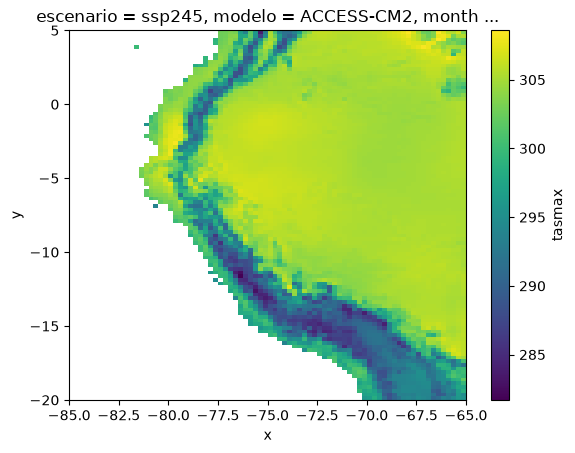

In [24]:
# Dominio: un mes cualquiera del histórico, para confirmar la extensión y forma de la grilla
#climatologia.sel(modelo="ACCESS-CM2",escenario="ssp245").isel(month=0).plot()

climatologia.sel(modelo="ACCESS-CM2",escenario="ssp245",month=12).plot()

#climatologia.sel(escenario="ssp245",month=12).plot(col='modelo')

#climatologia.sel(modelo="ACCESS-CM2",month=12).plot(col='escenario')
plt.show()

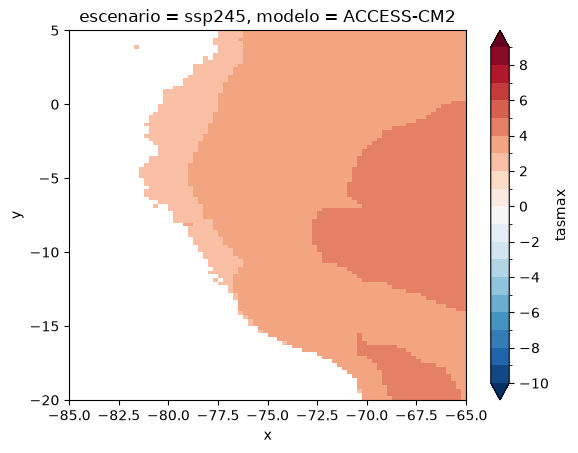

In [26]:
# Anomalía espacial: promedio de los últimos 10 años del siglo, SSP5-8.5
anomalia.sel(modelo="ACCESS-CM2",escenario="ssp245", time=slice("2090-01-01", "2099-12-31")).mean("time").plot(
    cmap="RdBu_r", center=0, levels=np.arange(-10,10), extend='both',
)
plt.show()

# Gráfico de anomalía para cada mes
#anomalia.sel(modelo="ACCESS-CM2",escenario="ssp245", time=slice("2090-01-01", "2099-12-31")).plot(
#    cmap="RdBu_r", center=0, levels=np.arange(-10,10), extend='both', col='time', col_wrap=3
#)
#plt.show()

### Ejercicio 1

Vuelve a calcular climatología y anomalía para ` "ACCESS-CM2" - "ssps585")`, esta vez con un periodo base distinto (por ejemplo, todo el histórico 1950-2014 en vez de 1985-2014).

Compara la anomalía de un mismo mes (por ejemplo junio de 2090) entre ambos periodos base. ¿Cuánto cambia? 

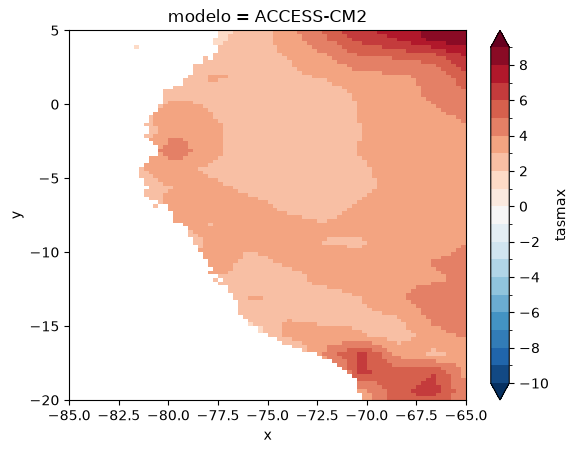

In [ ]:
# Se define el periodo
nuevo_periodo = (1950, 2014)
climatologia2, anomalia2 = calcular_climatologia_anomalia(datos_completo, nuevo_periodo)

# Se selecciona el periodo de cada anomalía calculada
marzo_2050_anom = anomalia.sel(modelo='ACCESS-CM2',escenario='ssp245', time=slice("2050-03-01", "2050-03-31")).mean("time")
marzo_2050_anom2 = anomalia2.sel(modelo='ACCESS-CM2',escenario='ssp585', time=slice("2050-03-01", "2050-03-31")).mean("time")

diferencia = marzo_2050_anom2 - marzo_2050_anom

diferencia.plot(cmap="RdBu_r", center=0, levels=np.arange(-10,10), extend='both')

## 5. Promedio espacial (ponderado por latitud)

Para pasar de la grilla a una sola serie de tiempo por modelo y escenario, promediamos sobre el espacio ponderando la latitud ([.wighted()](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.weighted.html)). La región es opcional, si no se especifica se usa todo el dominio descargado, pero se puede acotar a una subregión dentro de él.

In [27]:
# Se define una función que recorta las coordenadas del dataArray y saca un promedio de los datos
def promedio_espacial(dataarray, lon_min=None, lon_max=None, lat_min=None, lat_max=None):
    # Recorte
    sub = dataarray
    if lon_min is not None or lon_max is not None:
        sub = sub.sel(x=slice(lon_min, lon_max))
    if lat_min is not None or lat_max is not None:
        sub = sub.sel(y=slice(lat_max, lat_min))

    # ponderamos por cos(lat): una celda cerca del ecuador cubre más área real
    # que una celda cerca de los 20°S, aunque ambas midan lo mismo en grados
    pesos = np.cos(np.deg2rad(sub["y"]))
    # sub.weighted(pesos): Vincula los pesos calculados a la dimensión espacial correspondiente (y)
    # .mean(dim=("y", "x")): Colapsa las dos dimensiones espaciales y calcula la media sobre el área
    return sub.weighted(pesos).mean(dim=("y", "x"))

In [28]:
# todo el dominio descargado

series_regionales = promedio_espacial(anomalia)

# Prueba para una subregión opcional (descomenta para probar)
# sub = promedio_espacial(anomalia.sel(modelo="ACCESS-CM2", escenario="ssps585"), lon_min=-80, lon_max=-70, lat_min=-15, lat_max=0)

In [35]:
series_regionales.sel(modelo="ACCESS-CM2",escenario="ssp245")

<xarray.DataArray 'tasmax' (time: 1800)> Size: 14kB
array([-1.23426993, -1.44340491, -1.19485356, ...,  4.77608601,
        3.07932534,  2.51882138], shape=(1800,))
Coordinates:
  * time       (time) datetime64[ns] 14kB 1950-01-01 1950-02-01 ... 2099-12-01
    month      (time) int64 14kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
    escenario  <U6 24B 'ssp245'
    modelo     <U10 40B 'ACCESS-CM2'
Attributes:
    id:             tasmax
    data_type:      {'type': 'PixelType', 'precision': 'float'}
    crs:            EPSG:4326
    crs_transform:  [1 0 0 0 1 0]

## 6. De mensual a anual

In [30]:
series_anuales = series_regionales.groupby("time.year").mean("time")

In [31]:
series_anuales

<xarray.DataArray 'tasmax' (modelo: 2, escenario: 2, year: 150)> Size: 5kB
array([[[-7.89683500e-01,  1.86816480e-02, -6.33012503e-01,
         -2.83318592e-01, -3.48644506e-01, -4.69331715e-02,
         -1.00347563e+00, -3.96042388e-01, -3.20837885e-01,
         -4.37789032e-01, -1.73157390e-01, -2.06879739e-01,
         -4.72613528e-01, -1.16782628e+00, -5.23975252e-01,
         -9.88826869e-01, -9.86590243e-01, -1.04112395e+00,
         -2.91743135e-01, -2.73685966e-01, -5.55506102e-01,
         -1.04026579e+00, -4.81827030e-01,  2.73034543e-01,
         -1.04043003e+00, -1.10969278e+00, -6.72668188e-01,
         -5.99445056e-01, -5.02929301e-01, -2.87399209e-01,
         -2.92401839e-01, -2.16038796e-01, -7.20629421e-01,
         -6.02032306e-01, -1.23600197e-01, -2.32426825e-02,
          1.27351602e-01, -1.14573264e+00, -7.01526842e-01,
         -1.94302646e-01,  8.40840892e-01, -2.75046220e-03,
         -1.11227411e+00, -2.70469839e-01, -2.25121379e-01,
         -3.37878402e-01, -1.49408627e-02, -5.09331064e-01,
         -2.26926543e-01, -2.10616661e-02,  2.65164804e-01,
         -2.04660032e-01, -2.89117836e-02,  3.51765327e-01,
          3.92920898e-01,  7.64256319e-01,  2.43707756e-01,
         -4.93990681e-01, -1.54741964e-01,  1.71968043e-01,
...
          2.33615715e+00,  1.00833497e+00,  7.27761034e-01,
          1.02715663e+00,  1.84797245e+00,  2.74547935e+00,
          1.44962434e+00,  1.50726927e+00,  1.61377887e+00,
          2.30596683e+00,  2.71764757e+00,  2.91058826e+00,
          2.02088498e+00,  1.44091378e+00,  1.92743000e+00,
          2.08713861e+00,  2.47679981e+00,  3.01319285e+00,
          3.32143641e+00,  2.22025058e+00,  2.58132778e+00,
          3.06978691e+00,  3.73949769e+00,  3.07808283e+00,
          3.25756028e+00,  4.12663027e+00,  3.90908468e+00,
          2.79371281e+00,  3.06102472e+00,  3.68345320e+00,
          4.45016008e+00,  4.16246860e+00,  3.31824762e+00,
          3.95940126e+00,  4.49389964e+00,  4.76006638e+00,
          4.40029837e+00,  3.52984845e+00,  3.36075992e+00,
          4.46328765e+00,  5.07552573e+00,  4.19697641e+00,
          4.39751099e+00,  4.52552030e+00,  4.21357848e+00,
          4.51430281e+00,  5.43906577e+00,  5.25790271e+00,
          4.78930144e+00,  4.62161244e+00,  4.89728047e+00,
          5.66374906e+00,  5.72136966e+00,  4.65202168e+00,
          5.05534396e+00,  6.08978135e+00,  6.25568967e+00,
          5.35152235e+00,  5.52576145e+00,  6.11150745e+00]]])
Coordinates:
  * modelo     (modelo) <U10 80B 'ACCESS-CM2' 'CMCC-ESM2'
  * escenario  (escenario) <U6 48B 'ssp245' 'ssp585'
  * year       (year) int64 1kB 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099
Attributes:
    id:             tasmax
    data_type:      {'type': 'PixelType', 'precision': 'float'}
    crs:            EPSG:4326
    crs_transform:  [1 0 0 0 1 0]

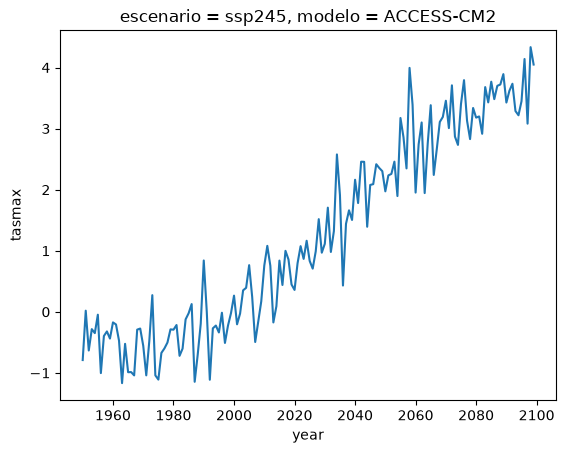

In [33]:
series_anuales.sel(modelo="ACCESS-CM2",escenario="ssp245").plot()

#series_anuales.sel(modelo="ACCESS-CM2").plot()

## 7. Test de tendencia (prueba)

 `kendalltau` para significancia, `theilslopes` para la magnitud.

In [37]:
def interpretar_tendencia(tau, p_valor, alpha=0.05):
    if p_valor < alpha and tau > 0:
        return "creciente"
    elif p_valor < alpha and tau < 0:
        return "decreciente"
    return "sin tendencia significativa"

serie_prueba = series_anuales.sel(modelo="ACCESS-CM2", escenario="ssp585")
anios = serie_prueba["year"].values
valores = serie_prueba.values

tau, p_valor = kendalltau(anios, valores)
pendiente, intercepto, ic_bajo, ic_alto = theilslopes(valores, anios, alpha=0.95)

print(f"ACCESS-CM2, ssp585: tau={tau:.3f}, p-valor={p_valor:.2e} -> {interpretar_tendencia(tau, p_valor)}")
print(f"Pendiente de Sen: {pendiente*10:.3f} °C/década (IC 95%: [{ic_bajo*10:.3f}, {ic_alto*10:.3f}])")

ACCESS-CM2, ssp585: tau=0.836, p-valor=4.88e-52 -> creciente
Pendiente de Sen: 0.571 °C/década (IC 95%: [0.523, 0.618])


### Ejercicio 2

Con el ejemplo de arriba como guía y el notebook `proyecciones_climaticas.ipynb`, aplica `kendalltau` y `theilslopes` a las **4 combinaciones** de `series_anuales` (2 modelos × 2 escenarios) en una interación, y junta los resultados en una tabla (`pd.DataFrame`).

¿Qué tanto difiere SSP2-4.5 de SSP5-8.5 dentro de un mismo modelo?

In [ ]:
#import pandas as pd
a = pd.dataframe({'':[],'':[],''})

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (1413598268.py, line 2)

In [ ]:
pd.dataframe = [columns='']

for modelo in modelos:
    for escenario in escenarios:
        s = series_anuales.sel(modelo=modelo, escenario=escenario)
        a = s["year"].values
        v = s.values
        tau, p_valor = kendalltau(a, v)
        pendiente, intercepto, ic_bajo, ic_alto = theilslopes(v, a, alpha=0.95)
        
        


ACCESS-CM2, ssp585: tau=0.789, p-valor=1.55e-46 -> creciente
Pendiente de Sen: 0.356 °C/década (IC 95%: [0.334, 0.376])
ACCESS-CM2, ssp585: tau=0.836, p-valor=4.88e-52 -> creciente
Pendiente de Sen: 0.571 °C/década (IC 95%: [0.523, 0.618])
ACCESS-CM2, ssp585: tau=0.743, p-valor=1.90e-41 -> creciente
Pendiente de Sen: 0.282 °C/década (IC 95%: [0.261, 0.302])
ACCESS-CM2, ssp585: tau=0.790, p-valor=1.22e-46 -> creciente
Pendiente de Sen: 0.433 °C/década (IC 95%: [0.397, 0.469])


#### Ensemble mean

In [ ]:
ensemble_mean = series_anuales.mean("modelo")   # o anomalia.mean("modelo") para el dataarray de anomalías (time,x,y)

## 8. Gráfico final

Con lo que ya procesaron: anomalía anual de `tasmax`, por modelo y escenario.

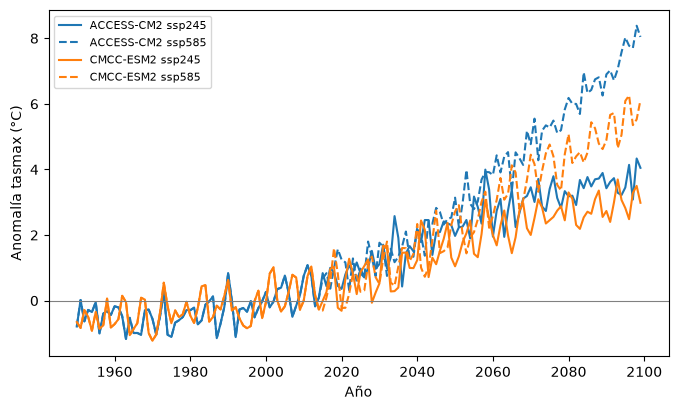

In [58]:
fig, ax = plt.subplots(figsize=(8, 4.5))

estilo_color = {"ACCESS-CM2": "tab:blue", "CMCC-ESM2": "tab:orange"}
estilo_linea = {"ssp245": "-", "ssp585": "--"}

for modelo in series_anuales.modelo.values:
    for escenario in series_anuales.escenario.values:
        serie = series_anuales.sel(modelo=modelo, escenario=escenario)
        ax.plot(serie["year"], serie.values,
            color=estilo_color[modelo], linestyle=estilo_linea[escenario],
            label=f"{modelo} {escenario}")

ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("Año")
ax.set_ylabel("Anomalía tasmax (°C)")
ax.legend(fontsize=8)
plt.show()

### Ejercicio 3

Grafica la media del ensamble (los 2 modelos) para cada escenario, junto con el rango entre ambos modelos (mínimo-máximo, no una desviación estándar, con solo 2 modelos no tiene sentido estadístico real).

Pista: `series_anuales.mean("modelo")`, `.min("modelo")` y `.max("modelo")`, luego `fill_between` entre el mínimo y el máximo.

In [ ]:
# tu código aquí

### Ejercicio 4 

Grafica un mapa con cartopy comparando el cambio espacial de `tasmax` entre escenarios: por ejemplo, la anomalía media 2070-2099 de SSP2-4.5 junto a la de SSP5-8.5 (dos subplots), para uno de los dos modelos.

Pistas: usa `plt.subplots(1, 2, subplot_kw={"projection": ccrs.PlateCarree()})`, y el patrón de `ax.contourf(...)` + `ax.coastlines()`.

In [ ]:
# tu código aquí